In [ ]:
# CELL 1: Check GPU
import subprocess
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - FIX THIS FIRST")

Thu Apr  9 17:12:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# CELL 2: Create kaggle.json manually
import os, json

# PASTE YOUR VALUES HERE
KAGGLE_USERNAME = "suyashjaiswal005"   # your Kaggle username
KAGGLE_KEY = "KGAT_c2842e6d8262e2a37714114438b4f390"         # the token you copied

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Done. Testing...")

!kaggle datasets list --search "real fake faces" 2>&1 | head -5

Done. Testing...
ref                                                             title                                            size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ----------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
xhlulu/140k-real-and-fake-faces                                 140k Real and Fake Faces                   4024555718  2020-02-10 17:11:35.030000          40956        215  0.7647059        
sachchitkunichetty/rvf10k                                       Real vs Fake Faces - 10k                    286539054  2024-03-09 19:24:25.637000           3819         45  0.88235295       


In [ ]:
# CELL 3: Download dataset
!kaggle datasets download -d sachchitkunichetty/rvf10k
!unzip -q rvf10k.zip -d /content/dataset
!find /content/dataset -type d | head -20
!find /content/dataset -name "*.jpg" | wc -l

Dataset URL: https://www.kaggle.com/datasets/sachchitkunichetty/rvf10k
License(s): CC-BY-NC-SA-4.0
100% 273M/273M [00:01<00:00, 210MB/s]

/content/dataset
/content/dataset/rvf10k
/content/dataset/rvf10k/train
/content/dataset/rvf10k/train/real
/content/dataset/rvf10k/train/fake
/content/dataset/rvf10k/valid
/content/dataset/rvf10k/valid/real
/content/dataset/rvf10k/valid/fake
10000


In [ ]:
# CELL 4: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# CELL 5: Data loaders
BATCH = 64
IMG_SIZE = 128

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = datasets.ImageFolder('/content/dataset/rvf10k/train', transform=train_tf)
val_ds   = datasets.ImageFolder('/content/dataset/rvf10k/valid', transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)

print("Classes:", train_ds.classes)
print("Train:", len(train_ds), "| Val:", len(val_ds))

Classes: ['fake', 'real']
Train: 7000 | Val: 3000


In [ ]:
# CELL 6: Custom CNN
class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 128),          nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = DeepfakeCNN().to(DEVICE)

# Count params
total = sum(p.numel() for p in model.parameters())
print(f"Total params: {total:,}")
print(model)

Total params: 9,038,626
DeepfakeCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   

In [ ]:
# CELL 7: Train
EPOCHS = 20
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    t_loss, t_correct = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()

    # --- Validate ---
    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            v_loss += criterion(out, labels).item()
            v_correct += (out.argmax(1) == labels).sum().item()

    scheduler.step()

    t_acc = t_correct / len(train_ds)
    v_acc = v_correct / len(val_ds)
    history['train_loss'].append(t_loss / len(train_loader))
    history['val_loss'].append(v_loss / len(val_loader))
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss/len(train_loader):.4f} Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss/len(val_loader):.4f} Acc: {v_acc:.4f}")

print(f"\nTraining done. Best Val Acc: {max(history['val_acc']):.4f}")

Epoch 01/20 | Train Loss: 0.7811 Acc: 0.5070 | Val Loss: 0.6928 Acc: 0.5233
Epoch 02/20 | Train Loss: 0.7000 Acc: 0.5067 | Val Loss: 0.6918 Acc: 0.5000
Epoch 03/20 | Train Loss: 0.6937 Acc: 0.5103 | Val Loss: 0.6929 Acc: 0.5423
Epoch 04/20 | Train Loss: 0.6942 Acc: 0.5167 | Val Loss: 0.6907 Acc: 0.5600
Epoch 05/20 | Train Loss: 0.6920 Acc: 0.5286 | Val Loss: 0.6908 Acc: 0.5550
Epoch 06/20 | Train Loss: 0.6937 Acc: 0.5189 | Val Loss: 0.6901 Acc: 0.5360
Epoch 07/20 | Train Loss: 0.6919 Acc: 0.5287 | Val Loss: 0.6886 Acc: 0.5537
Epoch 08/20 | Train Loss: 0.6885 Acc: 0.5350 | Val Loss: 0.6861 Acc: 0.5653
Epoch 09/20 | Train Loss: 0.6866 Acc: 0.5464 | Val Loss: 0.6850 Acc: 0.5453
Epoch 10/20 | Train Loss: 0.6852 Acc: 0.5500 | Val Loss: 0.6838 Acc: 0.5630
Epoch 11/20 | Train Loss: 0.6831 Acc: 0.5587 | Val Loss: 0.6797 Acc: 0.5777
Epoch 12/20 | Train Loss: 0.6820 Acc: 0.5656 | Val Loss: 0.6773 Acc: 0.6140
Epoch 13/20 | Train Loss: 0.6750 Acc: 0.5781 | Val Loss: 0.6756 Acc: 0.5890
Epoch 14/20 

In [ ]:
# CELL 8: Diagnose data
import os
for split in ['train', 'valid']:
    for cls in ['real', 'fake']:
        path = f'/content/dataset/rvf10k/{split}/{cls}'
        print(f"{split}/{cls}: {len(os.listdir(path))} images")

print("\nClass mapping:", train_ds.class_to_idx)

# Visualize sample batch
imgs, labels = next(iter(train_loader))
print("Batch shape:", imgs.shape)
print("Label distribution in batch:", labels.bincount())

train/real: 3500 images
train/fake: 3500 images
valid/real: 1500 images
valid/fake: 1500 images

Class mapping: {'fake': 0, 'real': 1}
Batch shape: torch.Size([64, 3, 128, 128])
Label distribution in batch: tensor([34, 30])


In [ ]:
# CELL 9: Fixed model + retrain from scratch
class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),    nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),      # less dropout

            nn.Conv2d(32, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),

            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = DeepfakeCNN().to(DEVICE)

EPOCHS = 25
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                  factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    t_loss, t_correct = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()

    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            v_loss += criterion(out, labels).item()
            v_correct += (out.argmax(1) == labels).sum().item()

    t_acc = t_correct / len(train_ds)
    v_acc = v_correct / len(val_ds)
    history['train_loss'].append(t_loss / len(train_loader))
    history['val_loss'].append(v_loss / len(val_loader))
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    scheduler.step(v_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss/len(train_loader):.4f} Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss/len(val_loader):.4f} Acc: {v_acc:.4f}")

print(f"\nBest Val Acc: {max(history['val_acc']):.4f}")

Epoch 01/25 | Train Loss: 0.8933 Acc: 0.5333 | Val Loss: 0.6891 Acc: 0.5493
Epoch 02/25 | Train Loss: 0.6778 Acc: 0.5689 | Val Loss: 0.6819 Acc: 0.5570
Epoch 03/25 | Train Loss: 0.6742 Acc: 0.5917 | Val Loss: 0.6700 Acc: 0.6080
Epoch 04/25 | Train Loss: 0.6649 Acc: 0.6027 | Val Loss: 0.6556 Acc: 0.6120
Epoch 05/25 | Train Loss: 0.6580 Acc: 0.6156 | Val Loss: 0.6439 Acc: 0.6307
Epoch 06/25 | Train Loss: 0.6389 Acc: 0.6394 | Val Loss: 0.6392 Acc: 0.6347
Epoch 07/25 | Train Loss: 0.6206 Acc: 0.6607 | Val Loss: 0.6104 Acc: 0.6767
Epoch 08/25 | Train Loss: 0.6072 Acc: 0.6731 | Val Loss: 0.5773 Acc: 0.7047
Epoch 09/25 | Train Loss: 0.5775 Acc: 0.7014 | Val Loss: 0.5593 Acc: 0.7253
Epoch 10/25 | Train Loss: 0.5570 Acc: 0.7197 | Val Loss: 0.5607 Acc: 0.7103
Epoch 11/25 | Train Loss: 0.5517 Acc: 0.7224 | Val Loss: 0.5302 Acc: 0.7457
Epoch 12/25 | Train Loss: 0.5193 Acc: 0.7426 | Val Loss: 0.5019 Acc: 0.7587
Epoch 13/25 | Train Loss: 0.5068 Acc: 0.7519 | Val Loss: 0.4869 Acc: 0.7797
Epoch 14/25 

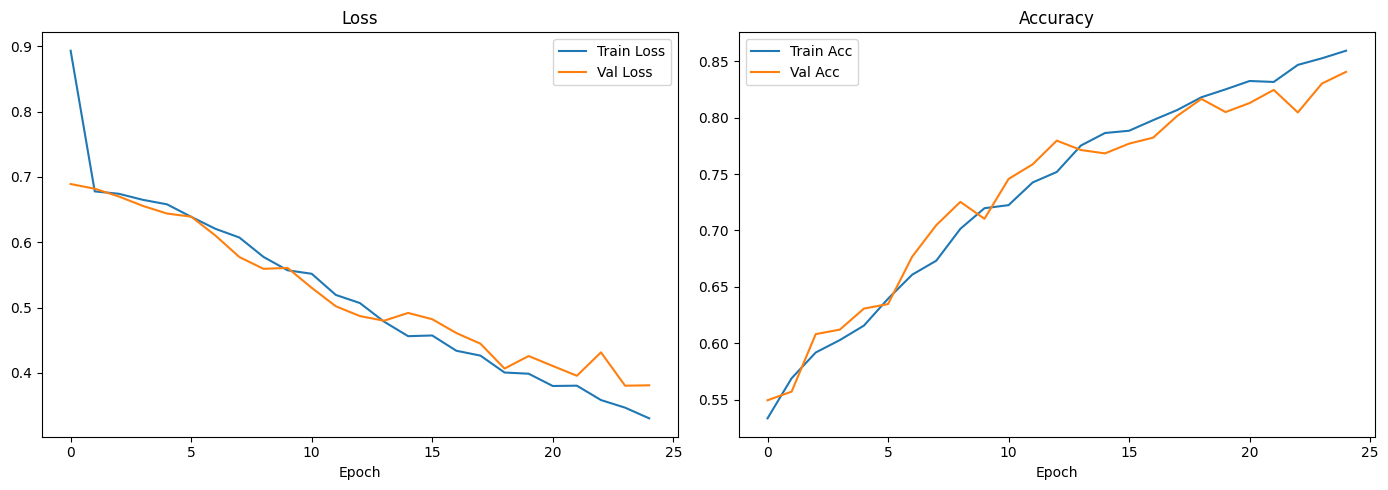

              precision    recall  f1-score   support

        fake       0.86      0.81      0.84      1500
        real       0.82      0.87      0.85      1500

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



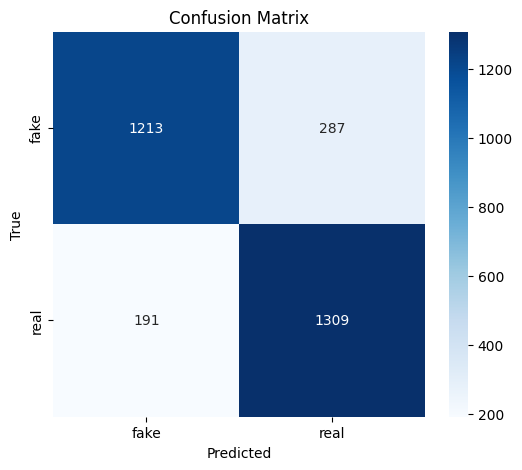

In [ ]:
# CELL 10: Plots + classification report
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Confusion matrix + report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
      target_names=train_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# CELL 11: Save model + test inference
torch.save(model.state_dict(), 'deepfake_cnn.pth')
print("Model saved.")

# Test on single image from val set
from PIL import Image
import random, os

def predict(img_path):
    img = Image.open(img_path).convert('RGB')
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        out = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_class = train_ds.classes[pred_idx]
        confidence = probs[pred_idx].item()
    return pred_class, confidence

# Test 5 random images
for cls in ['fake', 'real']:
    folder = f'/content/dataset/rvf10k/valid/{cls}'
    samples = random.sample(os.listdir(folder), 3)
    for fname in samples:
        path = os.path.join(folder, fname)
        pred, conf = predict(path)
        status = "✓" if pred == cls else "✗"
        print(f"{status} True:{cls:4s} | Pred:{pred:4s} | Conf:{conf:.3f} | {fname}")

Model saved.
✗ True:fake | Pred:real | Conf:0.877 | UL1TEXUBYH.jpg
✗ True:fake | Pred:real | Conf:0.996 | R6A78CZ0DX.jpg
✓ True:fake | Pred:fake | Conf:1.000 | 146AWCPVIY.jpg
✓ True:real | Pred:real | Conf:0.896 | 18553.jpg
✓ True:real | Pred:real | Conf:0.910 | 11899.jpg
✓ True:real | Pred:real | Conf:0.899 | 11797.jpg


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from google.colab import files

# Upload .pth file
uploaded = files.upload()  # select deepfake_cnn.pth

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),    nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(32, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = DeepfakeCNN().to(DEVICE)
model.load_state_dict(torch.load('deepfake_cnn.pth', map_location=DEVICE))
model.eval()

# Hardcoded from training — {'fake': 0, 'real': 1}
CLASS_NAMES = ['fake', 'real']
print("Ready. Device:", DEVICE)

Saving deepfake_cnn.pth to deepfake_cnn.pth
Ready. Device: cuda


In [ ]:
# CELL 1: Find best datasets on Kaggle
!kaggle datasets list --search "deepfake detection faces manipulation" | head -20
!echo "---"
!kaggle datasets list --search "face forensics manipulation real fake" | head -20

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
---
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
import os, json
from google.colab import files

# Option A: re-upload kaggle.json if you have it
# uploaded = files.upload()

# Option B: paste credentials directly
KAGGLE_USERNAME = "suyashjaiswal005"
KAGGLE_KEY = "KGAT_c2842e6d8262e2a37714114438b4f390"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets list --search "face forensics fake" 2>&1 | head -10

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal              GRAVEX-200K                                         1956337932  2025-05-27 16:20:45.603000           3617         43  0.7647059        
sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset  Deep Fake Detection (DFD) Entire Original Dataset  24156501909  2024-08-10 11:48:58.853000          19472        122  0.8125           
yuvrajpaikhot/extracted-deepfake-frames                          Extracted Deepfake Frames                           1113330549  2025-04-08 18:26:49.117000            123          1  0.75         

In [ ]:
# CELL 2: Download datasets
!kaggle datasets download -d yuvrajpaikhot/extracted-deepfake-frames
!kaggle datasets download -d furkankocaman/celeb-df-v2-content-aware-keyframes-faces-only

!mkdir -p /content/data1 /content/data2
!unzip -q extracted-deepfake-frames.zip -d /content/data1
!unzip -q celeb-df-v2-content-aware-keyframes-faces-only.zip -d /content/data2

# Inspect structure
!echo "=== Dataset 1 ===" && find /content/data1 -type d | head -20
!echo "=== Dataset 2 ===" && find /content/data2 -type d | head -20
!echo "=== Image counts ==="
!find /content/data1 -name "*.jpg" -o -name "*.png" | wc -l
!find /content/data2 -name "*.jpg" -o -name "*.png" | wc -l

Dataset URL: https://www.kaggle.com/datasets/yuvrajpaikhot/extracted-deepfake-frames
License(s): CC0-1.0
100% 1.04G/1.04G [00:10<00:00, 104MB/s]

Dataset URL: https://www.kaggle.com/datasets/furkankocaman/celeb-df-v2-content-aware-keyframes-faces-only
License(s): apache-2.0
100% 1.53G/1.53G [00:21<00:00, 77.3MB/s]

=== Dataset 1 ===
/content/data1
/content/data1/train
/content/data1/train/real_train_01519
/content/data1/train/fake_train_01092
/content/data1/train/fake_train_00218
/content/data1/train/fake_train_00514
/content/data1/train/fake_train_01501
/content/data1/train/fake_train_02159
/content/data1/train/fake_train_02128
/content/data1/train/fake_train_00640
/content/data1/train/fake_train_01559
/content/data1/train/fake_train_01293
/content/data1/train/fake_train_00798
/content/data1/train/real_train_01119
/content/data1/train/fake_train_01933
/content/data1/train/fake_train_00079
/content/data1/train/fake_train_00070
/content/data1/train/fake_train_00751
/content/data1/train/

In [ ]:
# CELL 3: Inspect full structure + merge
import os, shutil
from pathlib import Path

# Check dataset 1 splits
print("=== DS1 splits ===")
!find /content/data1 -type d -maxdepth 2 | sort

print("=== DS2 full structure ===")
!find /content/data2 -type d -maxdepth 3 | sort

# Count real vs fake in each
import os
def count_images(folder):
    exts = {'.jpg','.jpeg','.png'}
    return sum(1 for f in Path(folder).rglob('*') if f.suffix.lower() in exts)

for root, dirs, files in os.walk('/content/data1/train'):
    if any(f.lower().endswith(('.jpg','.png')) for f in files):
        print(f"DS1 {root}: {len(files)}")
        break

print("\nDS2 fake count:", count_images('/content/data2/processed_data_keyframes/fake'))
!find /content/data2/processed_data_keyframes -type d -maxdepth 1

Streaming output truncated to the last 5000 lines.
/content/data2/processed_data_keyframes/fake/fake_id25_id20_0005
/content/data2/processed_data_keyframes/fake/fake_id25_id20_0007
/content/data2/processed_data_keyframes/fake/fake_id25_id20_0008
/content/data2/processed_data_keyframes/fake/fake_id25_id20_0010
/content/data2/processed_data_keyframes/fake/fake_id25_id21_0002
/content/data2/processed_data_keyframes/fake/fake_id25_id21_0003
/content/data2/processed_data_keyframes/fake/fake_id25_id21_0005
/content/data2/processed_data_keyframes/fake/fake_id25_id21_0007
/content/data2/processed_data_keyframes/fake/fake_id25_id21_0008
/content/data2/processed_data_keyframes/fake/fake_id25_id21_0010
/content/data2/processed_data_keyframes/fake/fake_id25_id22_0002
/content/data2/processed_data_keyframes/fake/fake_id25_id22_0003
/content/data2/processed_data_keyframes/fake/fake_id25_id22_0004
/content/data2/processed_data_keyframes/fake/fake_id25_id22_0007
/content/data2/processed_data_keyframes

In [ ]:
# CELL 4: Merge both datasets into unified train/val split
import os, shutil, random
from pathlib import Path

random.seed(42)

# Output dirs
for split in ['train', 'val']:
    for cls in ['fake', 'real']:
        os.makedirs(f'/content/unified/{split}/{cls}', exist_ok=True)

def collect_images(root, label):
    """Collect all images from nested subdirs"""
    exts = {'.jpg', '.jpeg', '.png'}
    imgs = []
    for f in Path(root).rglob('*'):
        if f.suffix.lower() in exts:
            imgs.append((str(f), label))
    return imgs

# DS1 - already has train/valid split, use it directly
ds1_train_fake = collect_images('/content/data1/train', 'fake')
ds1_train_fake = [(p,l) for p,l in ds1_train_fake if 'fake' in p.lower()]
ds1_train_real = [(p,l) for p,l in collect_images('/content/data1/train', 'real') if 'real' in p.lower()]

# DS2 - no split, do 85/15
ds2_fake = collect_images('/content/data2/processed_data_keyframes/fake', 'fake')
ds2_real = collect_images('/content/data2/processed_data_keyframes/real', 'real')

def split_list(lst, ratio=0.85):
    random.shuffle(lst)
    n = int(len(lst)*ratio)
    return lst[:n], lst[n:]

ds2_fake_tr, ds2_fake_val = split_list(ds2_fake)
ds2_real_tr, ds2_real_val = split_list(ds2_real)

train_set = ds1_train_fake + ds1_train_real + ds2_fake_tr + ds2_real_tr
val_set   = ds2_fake_val + ds2_real_val

print(f"Train: {len(train_set)} | Val: {len(val_set)}")

# Copy files (symlink faster but copy safer)
def copy_split(items, split):
    for i, (src, label) in enumerate(items):
        ext = Path(src).suffix
        dst = f'/content/unified/{split}/{label}/{i:06d}{ext}'
        shutil.copy2(src, dst)

print("Copying train...")
copy_split(train_set, 'train')
print("Copying val...")
copy_split(val_set, 'val')

# Verify
for split in ['train','val']:
    for cls in ['fake','real']:
        n = len(os.listdir(f'/content/unified/{split}/{cls}'))
        print(f"{split}/{cls}: {n}")

Train: 143228 | Val: 14684
Copying train...
Copying val...
train/fake: 125567
train/real: 17661
val/fake: 12687
val/real: 1997


In [ ]:
# CELL 5: Imports + balanced loaders
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH = 64
IMG_SIZE = 128

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = datasets.ImageFolder('/content/unified/train', transform=train_tf)
val_ds   = datasets.ImageFolder('/content/unified/val',   transform=val_tf)

# Weighted sampler to balance classes
labels = [s[1] for s in train_ds.samples]
class_counts = np.bincount(labels)
weights = 1.0 / class_counts[labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2)

print("Classes:", train_ds.class_to_idx)
print("Train:", len(train_ds), "| Val:", len(val_ds))
print("Class counts:", class_counts)

Classes: {'fake': 0, 'real': 1}
Train: 143228 | Val: 14684
Class counts: [125567  17661]


In [ ]:
# CELL 6: Custom CNN (same architecture)
class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),    nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(32, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = DeepfakeCNN().to(DEVICE)
print("Params:", f"{sum(p.numel() for p in model.parameters()):,}")

Params: 8,973,730


In [ ]:
# CELL 7: Train with class-weighted loss
EPOCHS = 20

# Extra weight on real class since it's minority
class_weights = torch.tensor([1.0, 7.0]).to(DEVICE)  # fake=1, real=7
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS):
    model.train()
    t_loss, t_correct = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()

    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            v_loss += criterion(out, labels).item()
            v_correct += (out.argmax(1) == labels).sum().item()

    t_acc = t_correct / len(train_ds)
    v_acc = v_correct / len(val_ds)
    history['train_loss'].append(t_loss/len(train_loader))
    history['val_loss'].append(v_loss/len(val_loader))
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    scheduler.step(v_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss/len(train_loader):.4f} Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss/len(val_loader):.4f} Acc: {v_acc:.4f}")

print(f"\nBest Val Acc: {max(history['val_acc']):.4f}")

Epoch 01/20 | Train Loss: 0.3576 Acc: 0.5017 | Val Loss: 0.8811 Acc: 0.3593
Epoch 02/20 | Train Loss: 0.2852 Acc: 0.5882 | Val Loss: 0.3517 Acc: 0.8653
Epoch 03/20 | Train Loss: 0.2355 Acc: 0.7029 | Val Loss: 0.5764 Acc: 0.7597
Epoch 04/20 | Train Loss: 0.2048 Acc: 0.7543 | Val Loss: 0.3365 Acc: 0.8606
Epoch 05/20 | Train Loss: 0.1818 Acc: 0.7875 | Val Loss: 0.2944 Acc: 0.8797
Epoch 06/20 | Train Loss: 0.1691 Acc: 0.8040 | Val Loss: 0.4441 Acc: 0.8268
Epoch 07/20 | Train Loss: 0.1580 Acc: 0.8176 | Val Loss: 0.1443 Acc: 0.9419
Epoch 08/20 | Train Loss: 0.1532 Acc: 0.8241 | Val Loss: 0.4432 Acc: 0.8079
Epoch 09/20 | Train Loss: 0.1443 Acc: 0.8339 | Val Loss: 0.1709 Acc: 0.9338
Epoch 10/20 | Train Loss: 0.1387 Acc: 0.8414 | Val Loss: 0.2084 Acc: 0.9184
Epoch 11/20 | Train Loss: 0.1337 Acc: 0.8485 | Val Loss: 0.1736 Acc: 0.9289
Epoch 12/20 | Train Loss: 0.1123 Acc: 0.8730 | Val Loss: 0.1115 Acc: 0.9575
Epoch 13/20 | Train Loss: 0.1068 Acc: 0.8787 | Val Loss: 0.0853 Acc: 0.9660
Epoch 14/20 

Saved: deepfake_cnn_v2.pth


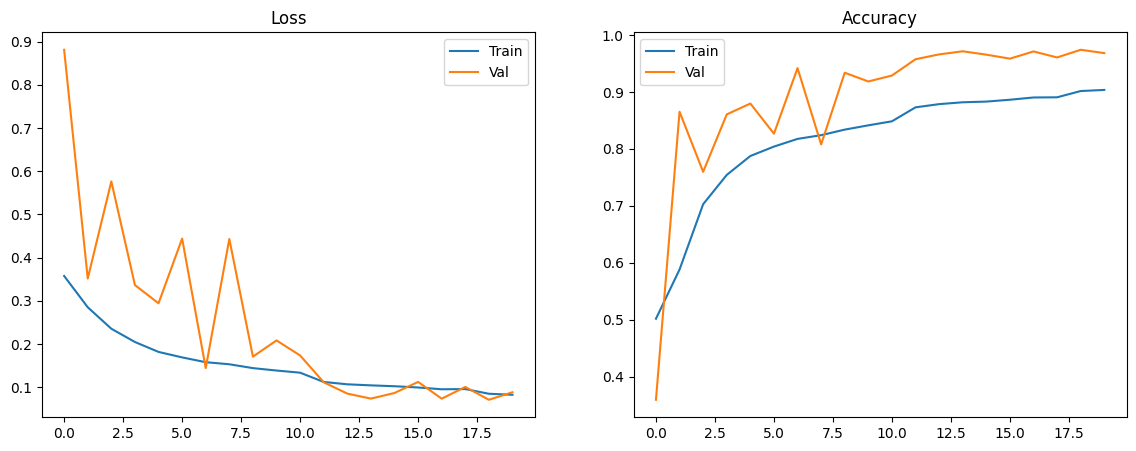

              precision    recall  f1-score   support

        fake       1.00      0.96      0.98     12687
        real       0.81      0.99      0.89      1997

    accuracy                           0.97     14684
   macro avg       0.91      0.98      0.94     14684
weighted avg       0.97      0.97      0.97     14684



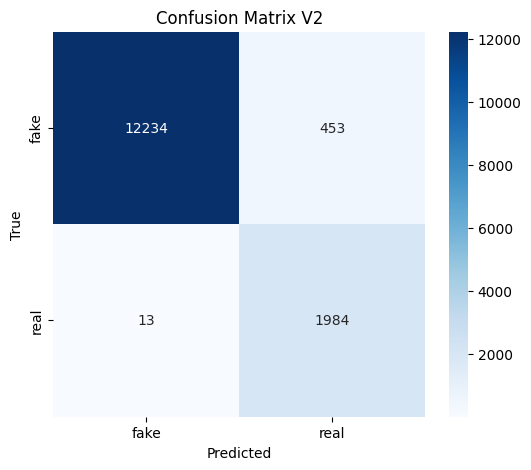

In [ ]:
# CELL 8: Save + evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

torch.save(model.state_dict(), 'deepfake_cnn_v2.pth')
print("Saved: deepfake_cnn_v2.pth")

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], label='Train'); ax1.plot(history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history['train_acc'], label='Train'); ax2.plot(history['val_acc'], label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.savefig('training_v2.png', dpi=150); plt.show()

# Confusion matrix
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        all_preds.extend(model(imgs).argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.title('Confusion Matrix V2'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.savefig('confusion_v2.png', dpi=150); plt.show()

In [ ]:
# CELL 9: Deploy v2
!pip install -q gradio

import gradio as gr

CLASS_NAMES = train_ds.classes  # ['fake', 'real']
model.eval()

def detect_deepfake(image):
    tensor = val_tf(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    fake_conf = probs[train_ds.class_to_idx['fake']].item()
    real_conf = probs[train_ds.class_to_idx['real']].item()
    label = "🔴 FAKE" if fake_conf > real_conf else "🟢 REAL"
    return {label: max(fake_conf, real_conf),
            "Fake probability": fake_conf,
            "Real probability": real_conf}

gr.Interface(
    fn=detect_deepfake,
    inputs=gr.Image(type="pil", label="Upload Face Image"),
    outputs=gr.Label(label="Result"),
    title="Deepfake Detector v2",
    description="Trained on face swaps + GAN faces. Upload any face image."
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3c7c62eb4099f5be54.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
# CELL A: Restore + deploy
import torch
import torch.nn as nn
from torchvision import transforms
import gradio as gr

!pip install -q gradio

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),    nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(32, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Upload .pth when prompted
from google.colab import files
uploaded = files.upload()  # select deepfake_cnn_v2.pth

model = DeepfakeCNN().to(DEVICE)
model.load_state_dict(torch.load('deepfake_cnn_v3.pth', map_location=DEVICE))
model.eval()
print("Loaded. Device:", DEVICE)

# class_to_idx from training: fake=0, real=1
def detect_deepfake(image):
    tensor = val_tf(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    fake_conf = probs[0].item()
    real_conf = probs[1].item()
    label = "🔴 FAKE" if fake_conf > real_conf else "🟢 REAL"
    return {label: max(fake_conf, real_conf),
            "Fake probability": fake_conf,
            "Real probability": real_conf}

gr.Interface(
    fn=detect_deepfake,
    inputs=gr.Image(type="pil", label="Upload Face Image"),
    outputs=gr.Label(label="Result"),
    title="Deepfake Detector v3",
    description="Detects GAN faces + face swaps. 97.4% accuracy."
).launch(share=True)

Saving deepfake_cnn_v3.pth to deepfake_cnn_v3 (1).pth
Loaded. Device: cuda
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://94cc6c0719918d81f7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [3]:
# Restore model + save inference script
import torch, torch.nn as nn

class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),    nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(32, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),   nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.1),
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                   nn.Dropout(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# Upload pth
from google.colab import files
uploaded = files.upload()  # upload deepfake_cnn_v3.pth

DEVICE = torch.device('cpu')  # CPU for Render free tier
model = DeepfakeCNN().to(DEVICE)
model.load_state_dict(torch.load('deepfake_cnn_v3.pth', map_location=DEVICE))
model.eval()

# Re-save as CPU model
torch.save(model.state_dict(), 'model_cpu.pth')
print("Saved model_cpu.pth")
files.download('model_cpu.pth')

Saving deepfake_cnn_v3.pth to deepfake_cnn_v3 (2).pth
Saved model_cpu.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, json
KAGGLE_USERNAME = "suyashjaiswal005"
KAGGLE_KEY = "KGAT_c2842e6d8262e2a37714114438b4f390"
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# This adds StyleGAN/GAN-generated fake faces
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d /content/data3
!find /content/data3 -type d | head -10
!find /content/data3 -name "*.jpg" | wc -l